In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
import math
import numpy as np
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
pd.set_option('display.max_columns', None)
plt.rcParams["figure.figsize"] = (15, 8)

## Load Data Set

In [117]:
df = pd.read_excel(r"C:\Users\dalal\Downloads\group_3_faa_data_subset\group_3_faa_data_subset\faa_data_subset.xlsx")
df

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,Aircraft: Number of engines,Collision Date and Time,When: Time of day,When: Phase of flight,Effect: Amount of damage (detailed),Effect: Impact to flight,Effect: Indicated Damage,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID,Number of Strikes,Record ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,None,None,No damage,NaN,0,NaN,0.0,NaN,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12,1,17459
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,None,None,No damage,NaN,0,NaN,NaN,NaN,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1,1,17114
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,Medium,Aborted Take-off,Caused damage,720.0,171132,30.000,0.0,0.0,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114,1,259361
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,None,None,No damage,15.0,600,0.625,NaN,NaN,Birds,Pigeons and Doves,Doves,Mourning dove,O2205,1,345167
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Medium,None,Caused damage,12.0,188245,0.500,NaN,0.0,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302,1,262782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28293,KYNG,YOUNGSTOWN-WARREN RGNL ARPT,Ohio,OH,United States,Airplane,4.0,2011-11-16 18:20:00,NaN,Approach,None,None,No damage,NaN,0,NaN,100.0,NaN,Birds,Perching Birds,Blackbirds,Rusty blackbird,ZT106,1,15818
28294,KYNG,YOUNGSTOWN-WARREN RGNL ARPT,Ohio,OH,United States,Airplane,4.0,2012-11-01 21:20:00,NaN,Approach,None,None,No damage,NaN,0,NaN,1900.0,NaN,Birds,"Ducks, Geese, Swans, Waterfowl",Ducks,Ruddy duck,J2140,1,16759
28295,KYNG,YOUNGSTOWN-WARREN RGNL ARPT,Ohio,OH,United States,Airplane,4.0,2014-05-07 22:00:00,NaN,Take-off run,None,None,No damage,NaN,0,NaN,NaN,NaN,Birds,Perching Birds,Sparrows,White-crowned sparrow,ZX309,1,17575
28296,KYNG,YOUNGSTOWN-WARREN RGNL ARPT,Ohio,OH,United States,Airplane,4.0,2013-10-28 18:30:00,NaN,Approach,None,None,No damage,NaN,0,NaN,NaN,NaN,Birds,Perching Birds,Waxwings,Cedar waxwing,ZD102,1,17262


In [118]:
#from github
#username = "StefanFSmid"
#repository = "ASDA_2025_Group_3_Porfolio"
#directory = "48-hour-exam/group_3_faa_data_subset/group_3_faa_data_subset/faa_data_subset.xlsx"

#github_url = f"https://raw.githubusercontent.com/{username}/{repository}/master/{directory}"
#df = pd.read_excel(github_url)


## Basic Data Inspection and Cleaning

In [119]:
#Checking the columns in the dataframe
df.columns

Index(['Airport: Code', 'Airport: Name', 'Origin State', 'Origin State Code',
       'Country', 'Aircraft: Type', 'Aircraft: Number of engines',
       'Collision Date and Time', 'When: Time of day', 'When: Phase of flight',
       'Effect: Amount of damage (detailed)', 'Effect: Impact to flight',
       'Effect: Indicated Damage',
       'Cost: Aircraft time out of service (hours)', 'Cost: Total $', 'Days',
       'Feet above ground', 'Miles from airport', 'Wildlife: Animal Category',
       'Wildlife: Species Order', 'Wildlife: Species Group',
       'Wildlife: Species', 'Wildlife: Species ID', 'Number of Strikes',
       'Record ID'],
      dtype='object')

In [120]:
# Display the shape of the dataframe
df.shape

(28298, 25)

In [121]:
# Display the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28298 entries, 0 to 28297
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Airport: Code                               28298 non-null  object        
 1   Airport: Name                               28298 non-null  object        
 2   Origin State                                28298 non-null  object        
 3   Origin State Code                           28298 non-null  object        
 4   Country                                     28298 non-null  object        
 5   Aircraft: Type                              27467 non-null  object        
 6   Aircraft: Number of engines                 25918 non-null  float64       
 7   Collision Date and Time                     28298 non-null  datetime64[ns]
 8   When: Time of day                           27655 non-null  object        
 9   When: 

In [122]:
# Understanding the shape of the data.
print('Total rows:',df.shape[0])
print('Total columns:',df.shape[1])

Total rows: 28298
Total columns: 25


In [123]:
# Display the first few rows of the dataframe
df.head()

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,Aircraft: Number of engines,Collision Date and Time,When: Time of day,When: Phase of flight,Effect: Amount of damage (detailed),Effect: Impact to flight,Effect: Indicated Damage,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID,Number of Strikes,Record ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,None,None,No damage,NaN,0,NaN,0.0,NaN,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12,1,17459
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,None,None,No damage,NaN,0,NaN,NaN,NaN,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1,1,17114
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,Medium,Aborted Take-off,Caused damage,720.0,171132,30.000,0.0,0.0,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114,1,259361
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,None,None,No damage,15.0,600,0.625,NaN,NaN,Birds,Pigeons and Doves,Doves,Mourning dove,O2205,1,345167
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Medium,None,Caused damage,12.0,188245,0.500,NaN,0.0,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302,1,262782


In [124]:
# Checking the categorical columns
df.select_dtypes(include=object).head()

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,When: Time of day,When: Phase of flight,Effect: Amount of damage (detailed),Effect: Impact to flight,Effect: Indicated Damage,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,Take-off run,None,None,No damage,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,NaN,Take-off run,None,None,No damage,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Day,Take-off run,Medium,Aborted Take-off,Caused damage,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Night,Approach,None,None,No damage,Birds,Pigeons and Doves,Doves,Mourning dove,O2205
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,Day,Approach,Medium,None,Caused damage,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302


In [125]:
# Checking the numerical columns
df.select_dtypes(include=np.number).head()

,Aircraft: Number of engines,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Number of Strikes,Record ID
0,NaN,NaN,0,NaN,0.0,NaN,1,17459
1,1.0,NaN,0,NaN,NaN,NaN,1,17114
2,2.0,720.0,171132,30.000,0.0,0.0,1,259361
3,2.0,15.0,600,0.625,NaN,NaN,1,345167
4,2.0,12.0,188245,0.500,NaN,0.0,1,262782


In [126]:
# Display the summary statistics of the dataframe
df.describe().round(0)

,Aircraft: Number of engines,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Number of Strikes,Record ID
count,25918.0,2929.0,28298.0,2929.0,24872.0,19807.0,28298.0,28298.0
mean,2.0,85.0,11385.0,4.0,339.0,0.0,1.0,271474.0
std,0.0,509.0,312536.0,21.0,1065.0,3.0,0.0,81859.0
min,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1164.0
25%,2.0,1.0,0.0,0.0,0.0,0.0,1.0,235364.0
50%,2.0,2.0,0.0,0.0,0.0,0.0,1.0,301697.0
75%,2.0,24.0,0.0,1.0,100.0,0.0,1.0,330425.0
max,4.0,21000.0,41071585.0,875.0,20000.0,100.0,1.0,360842.0


In [127]:
# display missing values

missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_values_percentage})
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df = missing_values_df.sort_values(by='Missing Values', ascending=False)
print(tabulate.tabulate(missing_values_df, headers='keys', tablefmt='psql'))


+--------------------------------------------+------------------+--------------+
|                                            |   Missing Values |   Percentage |
|--------------------------------------------+------------------+--------------|
| Cost: Aircraft time out of service (hours) |            25369 |    89.6494   |
| Days                                       |            25369 |    89.6494   |
| Miles from airport                         |             8491 |    30.0057   |
| Feet above ground                          |             3426 |    12.1069   |
| Aircraft: Number of engines                |             2380 |     8.41049  |
| Aircraft: Type                             |              831 |     2.9366   |
| When: Time of day                          |              643 |     2.27225  |
| When: Phase of flight                      |              406 |     1.43473  |
| Effect: Impact to flight                   |              214 |     0.756237 |
+---------------------------

In [128]:
df.columns = (
    df.columns
      .str.replace('$', '', regex=False)
      .str.strip()
      .str.lower()
      .str.replace(':', '', regex=False)  
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
      .str.replace(' ', '_', regex=False)
)

# Print the cleaned column names
print(df.columns)


Index(['airport_code', 'airport_name', 'origin_state', 'origin_state_code',
       'country', 'aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_amount_of_damage_detailed', 'effect_impact_to_flight',
       'effect_indicated_damage', 'cost_aircraft_time_out_of_service_hours',
       'cost_total', 'days', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category', 'wildlife_species_order',
       'wildlife_species_group', 'wildlife_species', 'wildlife_species_id',
       'number_of_strikes', 'record_id'],
      dtype='object')


In [129]:
#Check for duplicates

In [130]:
df[df.duplicated()]

,airport_code,airport_name,origin_state,origin_state_code,country,aircraft_type,aircraft_number_of_engines,collision_date_and_time,when_time_of_day,when_phase_of_flight,effect_amount_of_damage_detailed,effect_impact_to_flight,effect_indicated_damage,cost_aircraft_time_out_of_service_hours,cost_total,days,feet_above_ground,miles_from_airport,wildlife_animal_category,wildlife_species_order,wildlife_species_group,wildlife_species,wildlife_species_id,number_of_strikes,record_id


In [131]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [132]:
df["collision_date_and_time"].dtype

dtype('<M8[ns]')

In [133]:
df.columns

Index(['airport_code', 'airport_name', 'origin_state', 'origin_state_code',
       'country', 'aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_amount_of_damage_detailed', 'effect_impact_to_flight',
       'effect_indicated_damage', 'cost_aircraft_time_out_of_service_hours',
       'cost_total', 'days', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category', 'wildlife_species_order',
       'wildlife_species_group', 'wildlife_species', 'wildlife_species_id',
       'number_of_strikes', 'record_id'],
      dtype='object')

In [169]:
df.head()

,aircraft_type,aircraft_number_of_engines,collision_date_and_time,when_time_of_day,when_phase_of_flight,effect_indicated_damage,feet_above_ground,miles_from_airport,wildlife_animal_category,damage_flag,month
0,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,No damage,0.0,NaN,Terrestrial Mammals,0,9
1,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,No damage,NaN,NaN,Birds,0,4
2,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,Caused damage,0.0,0.0,Birds,1,4
3,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,No damage,NaN,NaN,Birds,0,4
4,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Caused damage,NaN,0.0,Birds,1,3


In [135]:
# Dropping unnecessary columns from the dataset

In [136]:
cols_to_drop = [
    "airport_code",
    "airport_name",
    "origin_state",
    "origin_state_code",
    "country",
    "wildlife_species_id",
    "record_id",
    "wildlife_species",
    "wildlife_species_group",
    "wildlife_species_order",
    "effect_amount_of_damage_detailed",
    "effect_impact_to_flight",
    "cost_aircraft_time_out_of_service_hours",
    "cost_total",
    "days",
    "number_of_strikes"
]

df = df.drop(columns=cols_to_drop)

In [137]:
df

,aircraft_type,aircraft_number_of_engines,collision_date_and_time,when_time_of_day,when_phase_of_flight,effect_indicated_damage,feet_above_ground,miles_from_airport,wildlife_animal_category
0,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,No damage,0.0,NaN,Terrestrial Mammals
1,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,No damage,NaN,NaN,Birds
2,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,Caused damage,0.0,0.0,Birds
3,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,No damage,NaN,NaN,Birds
4,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,Caused damage,NaN,0.0,Birds
...,...,...,...,...,...,...,...,...,...
28293,Airplane,4.0,2011-11-16 18:20:00,NaN,Approach,No damage,100.0,NaN,Birds
28294,Airplane,4.0,2012-11-01 21:20:00,NaN,Approach,No damage,1900.0,NaN,Birds
28295,Airplane,4.0,2014-05-07 22:00:00,NaN,Take-off run,No damage,NaN,NaN,Birds
28296,Airplane,4.0,2013-10-28 18:30:00,NaN,Approach,No damage,NaN,NaN,Birds


In [138]:
# Checking the dataframe columns left

In [139]:
df.columns

Index(['aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_indicated_damage', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category'],
      dtype='object')

In [140]:
# Reason for dropping the columns

## Exploratory Data Analysis

In [141]:
# Create binary target
df["damage_flag"] = (df["effect_indicated_damage"] == "Caused damage").astype(int)

# Class balance
df["damage_flag"].value_counts()
df["damage_flag"].value_counts(normalize=True)

0    0.890063
1    0.109937
Name: damage_flag, dtype: float64

In [142]:
# Create month variable

In [143]:
df["month"] = df["collision_date_and_time"].dt.month

In [144]:
# Numeric Variables

In [145]:
# Summary Statistics

In [146]:
num_cols = [
    "aircraft_number_of_engines",
    "feet_above_ground",
    "miles_from_airport"
]

df[num_cols].describe()

,aircraft_number_of_engines,feet_above_ground,miles_from_airport
count,25918.000000,24872.000000,19807.000000
mean,2.004707,338.847178,0.475153
std,0.369028,1064.706230,2.566334
min,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,2.000000,100.000000,0.000000
max,4.000000,20000.000000,100.000000


In [147]:
# Distribution Plots (Check Skewness)

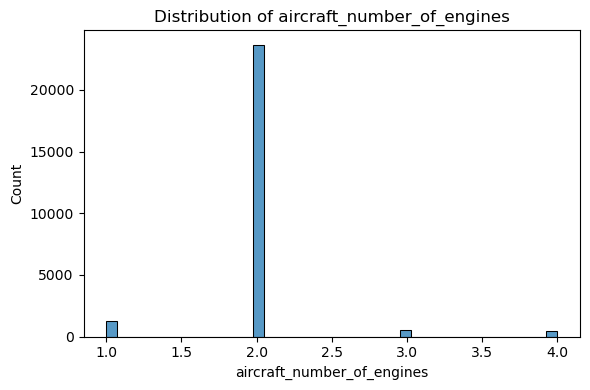

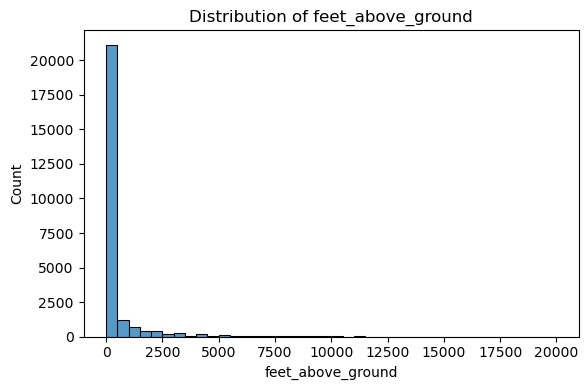

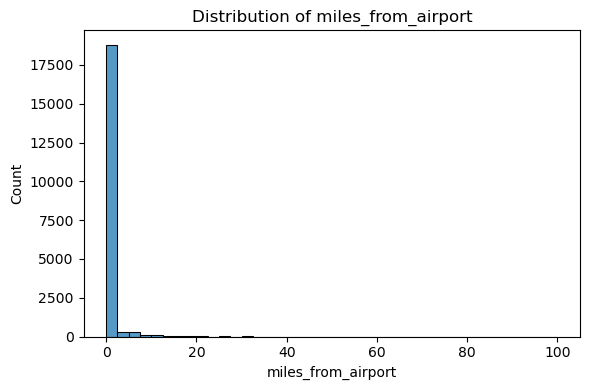

In [148]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=40)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [149]:
# Numeric Variables vs Damage

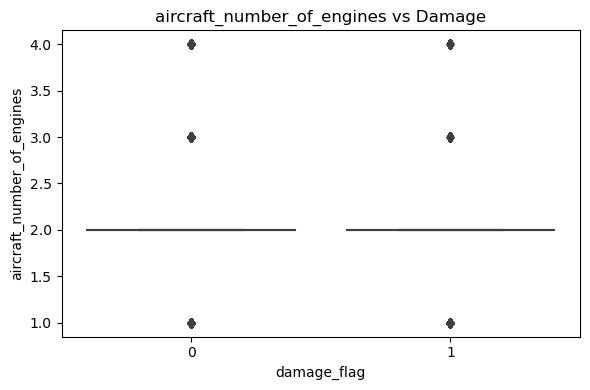

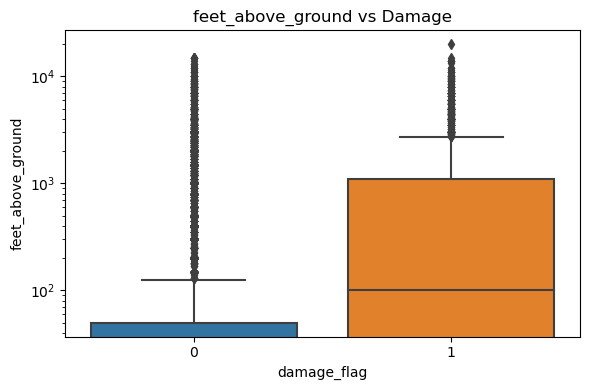

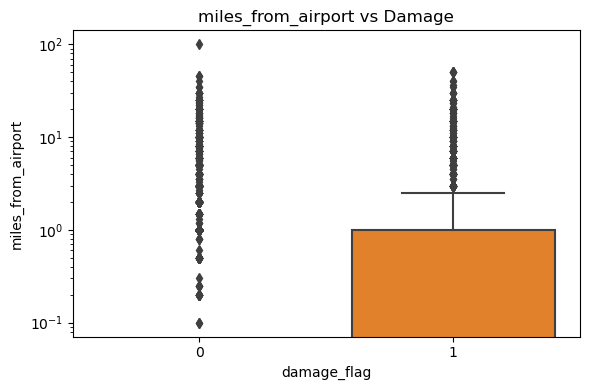

In [150]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="damage_flag", y=col)
    plt.title(f"{col} vs Damage")
    
    if col in ["feet_above_ground", "miles_from_airport"]:
        plt.yscale("log")
    
    plt.tight_layout()
    plt.show()

In [151]:
# Categorical Variables

In [152]:
# Damage Rate by Categorical Variables

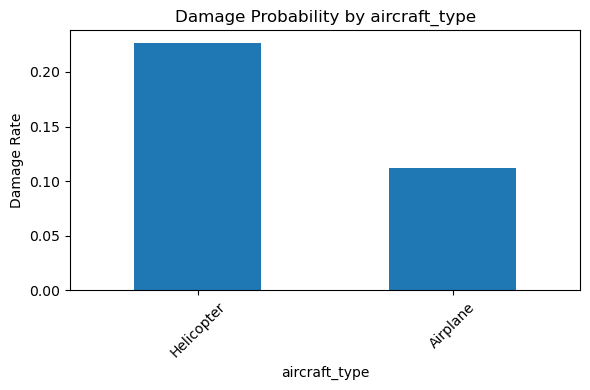

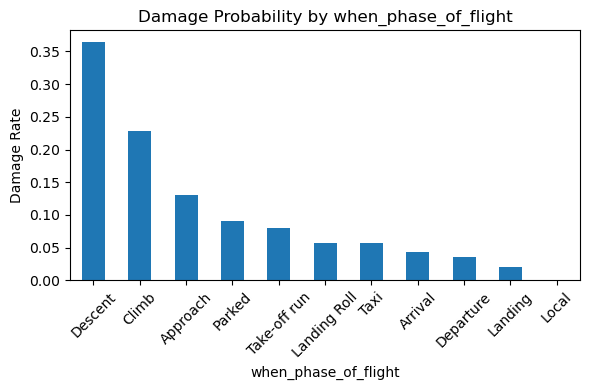

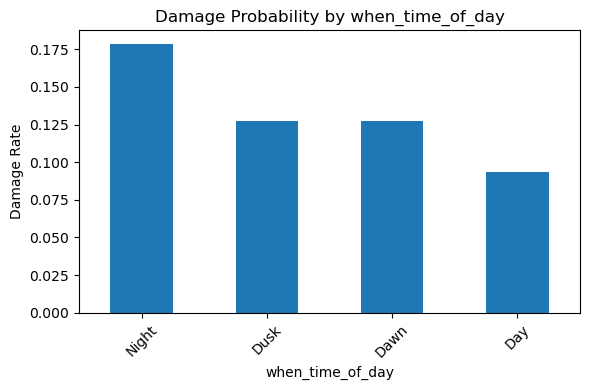

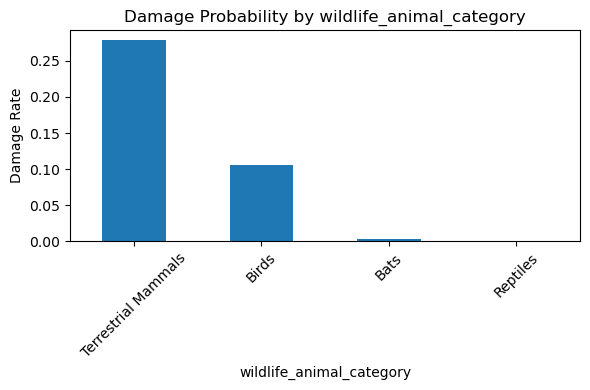

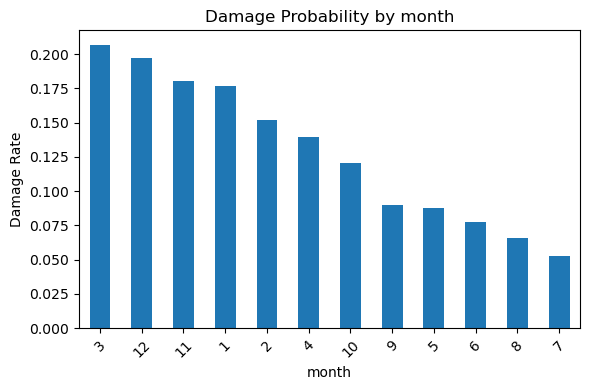

In [153]:
cat_cols = [
    "aircraft_type",
    "when_phase_of_flight",
    "when_time_of_day",
    "wildlife_animal_category",
    "month"
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    
    damage_rates = (
        df.groupby(col)["damage_flag"]
          .mean()
          .sort_values(ascending=False)
    )
    
    damage_rates.plot(kind="bar")
    plt.title(f"Damage Probability by {col}")
    plt.ylabel("Damage Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [154]:
# Phase of Flight — Stacked Percentage Plot

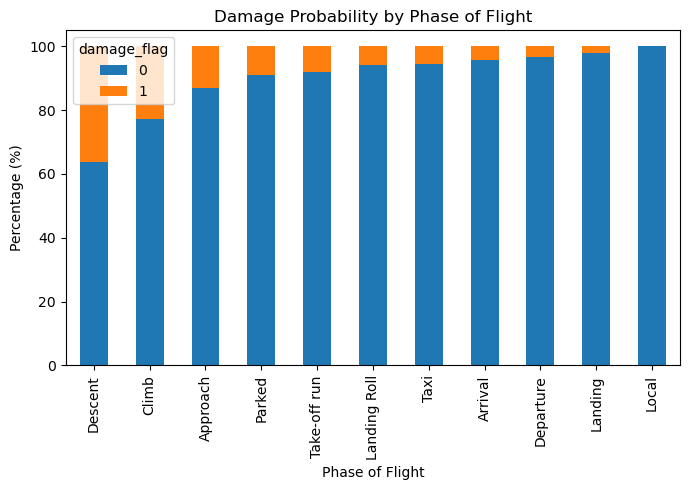

In [155]:
phase_damage = (
    pd.crosstab(
        df["when_phase_of_flight"],
        df["damage_flag"],
        normalize="index"
    ) * 100
)

phase_damage = phase_damage.sort_values(by=1, ascending=False)

ax = phase_damage.plot(kind="bar", stacked=True, figsize=(7,5))
ax.set_title("Damage Probability by Phase of Flight")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Phase of Flight")
plt.tight_layout()
plt.show()

In [156]:
# Correlation Check (Numeric Only)

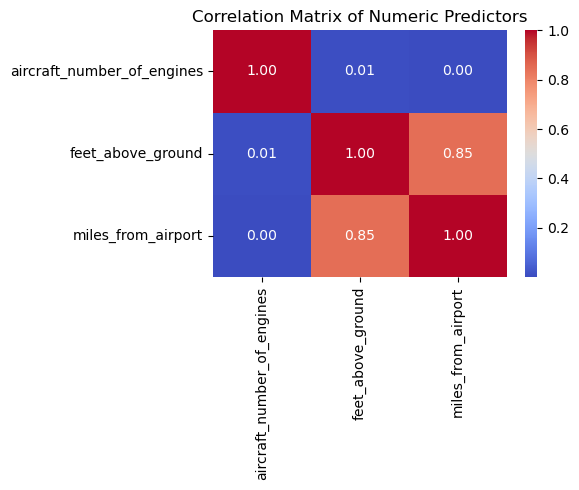

In [157]:
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Predictors")
plt.tight_layout()
plt.show()

In [158]:
# Checking null values again

In [159]:
df.isnull().sum()/len(df)*100

aircraft_type                  2.936603
aircraft_number_of_engines     8.410488
collision_date_and_time        0.000000
when_time_of_day               2.272245
when_phase_of_flight           1.434730
effect_indicated_damage        0.000000
feet_above_ground             12.106863
miles_from_airport            30.005654
wildlife_animal_category       0.000000
damage_flag                    0.000000
month                          0.000000
dtype: float64

In [160]:
# Dropping the null values

In [162]:
model_vars = [
    "damage_flag",
    "aircraft_type",
    "aircraft_number_of_engines",
    "when_phase_of_flight",
    "when_time_of_day",
    "feet_above_ground",
    "miles_from_airport",
    "wildlife_animal_category",
    "month"
]

model_df = df[model_vars].dropna()

print("Original shape:", df.shape)
print("Model shape after dropping NA:", model_df.shape)

Original shape: (28298, 11)
Model shape after dropping NA: (17670, 9)


In [163]:
# Comparing the damage proportion before and after dropping the null values

In [164]:
print("Original damage rate:", df["damage_flag"].mean())
print("Model damage rate:", model_df["damage_flag"].mean())

Original damage rate: 0.10993709802812919
Model damage rate: 0.09388794567062818


In [165]:
model_df

,damage_flag,aircraft_type,aircraft_number_of_engines,when_phase_of_flight,when_time_of_day,feet_above_ground,miles_from_airport,wildlife_animal_category,month
2,1,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,4
5,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,3
6,0,Airplane,3.0,Take-off run,Day,0.0,0.0,Birds,4
11,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,8
12,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,6
...,...,...,...,...,...,...,...,...,...
28276,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,7
28277,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,5
28278,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,7
28282,0,Airplane,2.0,Landing Roll,Dusk,0.0,0.0,Birds,9


In [166]:
# No null value is remaining

In [167]:
model_df.isnull().sum()

damage_flag                   0
aircraft_type                 0
aircraft_number_of_engines    0
when_phase_of_flight          0
when_time_of_day              0
feet_above_ground             0
miles_from_airport            0
wildlife_animal_category      0
month                         0
dtype: int64

In [168]:
model_df

,damage_flag,aircraft_type,aircraft_number_of_engines,when_phase_of_flight,when_time_of_day,feet_above_ground,miles_from_airport,wildlife_animal_category,month
2,1,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,4
5,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,3
6,0,Airplane,3.0,Take-off run,Day,0.0,0.0,Birds,4
11,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,8
12,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,6
...,...,...,...,...,...,...,...,...,...
28276,0,Airplane,2.0,Landing Roll,Day,0.0,0.0,Birds,7
28277,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,5
28278,0,Airplane,2.0,Take-off run,Day,0.0,0.0,Birds,7
28282,0,Airplane,2.0,Landing Roll,Dusk,0.0,0.0,Birds,9
